#### Import Libraries

In [151]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

from statsmodels.tsa.arima.model import ARIMA
import itertools
import pyfolio as pf

# Pyfolio compatibility patch for pandas >= 2.0
if not hasattr(pd.Series, "iteritems"):
    pd.Series.iteritems = pd.Series.items
if not hasattr(pd.DataFrame, "iteritems"):
    pd.DataFrame.iteritems = pd.DataFrame.items

print("Libraries loaded.")

Libraries loaded.


####  Load Data and Split

In [152]:
DATA_PATH = r"C:\Users\Hassa\OneDrive - Loughborough University\current\Algorithmic Trading for Beginners\FTSA\TSACapstoneTemplate\TSACapstoneTemplate\data_modules"

df_aud = pd.read_pickle(os.path.join(DATA_PATH, "fx_pair_1_5m.bz2"))
df_eur = pd.read_pickle(os.path.join(DATA_PATH, "fx_pair_2_5m.bz2"))

def resample_data(df):
    ohlcv_dict = {
                    'open': 'first',
                    'high': 'max',
                    'low': 'min',
                    'close': 'last',
                    'volume': 'sum'
                 }
    temp_df = df.resample('4H', label='right', closed='right').agg(ohlcv_dict).dropna()
    #temp_df.index = temp_df.index.tz_localize(None)
    return temp_df

# Resample the data into 4 hourly frequency
df_aud = resample_data(df_aud)
df_eur = resample_data(df_eur)
print(df_aud.shape)
print(df_eur.shape)

(4861, 5)
(4861, 5)


In [153]:
def sanity_check_02(df):
    # Adding check for missing data
    # Groupby data points available on each day
    temp = df.groupby(df.index.date).count()
    # Since the data is resampled to 4 hour frequency, there are 6 data points in one day
    temp = temp[temp['close']!=6]
    # View dates where the data is missing. Since we are dealing with hourly data, there will be 24 data points in 24 hours.
    print("Removing {} data points".format(len(temp)))
    '''
    To maintain consistent data, we consider the dates for which full data is available.
    A better option would be to use a reliable data source.
    '''
    to_delete = list(pd.to_datetime(temp.index))
    return df[~(df.index.isin(to_delete))]

df_aud = sanity_check_02(df_aud)
df_eur = sanity_check_02(df_eur)

Removing 169 data points
Removing 169 data points


In [154]:
def train_test_split_ts(df, ratio, pair_name):
    split = int(len(df) * ratio)
    train = df.iloc[:split].copy()
    test  = df.iloc[split:].copy()
    print(f"\n{pair_name}")
    print(f"  Train : {len(train):,} bars  "
          f"({train.index[0].date()} → {train.index[-1].date()})")
    print(f"  Test  : {len(test):,} bars  "
          f"({test.index[0].date()} → {test.index[-1].date()})")
    return train, test

train_aud, test_aud = train_test_split_ts(df_aud, TRAIN_RATIO, "AUD/USD")
train_eur, test_eur = train_test_split_ts(df_eur, TRAIN_RATIO, "EUR/USD")


AUD/USD
  Train : 3,284 bars  (2018-01-01 → 2020-02-11)
  Test  : 1,408 bars  (2020-02-11 → 2021-01-15)

EUR/USD
  Train : 3,284 bars  (2018-01-01 → 2020-02-11)
  Test  : 1,408 bars  (2020-02-11 → 2021-01-15)


In [155]:
def get_best_params(data):
    
    # Define the p, d and q parameters
    p = q = range(0, 5)
    d = range(1,2)

    # Generate all different combinations of p, d and q triplets
    pdq = list(itertools.product(p, d, q))

    best_aic = float("inf")
    best_param = None      

    for param in tqdm(pdq):
        try:
            model = ARIMA(data.close.values, order=param)
            model_fit = model.fit()
            if model_fit.aic < best_aic:
                best_param = param
                best_aic = model_fit.aic
        except:
            continue
            
    return best_param


best_param_aud = get_best_params(train_aud)
best_param_eur = get_best_params(train_eur)
best_paran_eur = (0, 1, 1)
print(f"The best parameter combination:")
print(f"AUD/USD: {best_param_aud}")
print(f"EUR/USD: {best_param_eur}")

100%|██████████| 25/25 [00:26<00:00,  1.07s/it]

The best parameter combination:
AUD/USD: (1, 1, 0)
EUR/USD: (0, 1, 0)


In [156]:
def get_predicted_prices(close_prices, best_param):
    
    # Define the best model
    best_model = ARIMA(close_prices.values, order=best_param)
    best_model_fit = best_model.fit(method_kwargs={"warn_convergence": False})

    # Make forecast
    predictions = best_model_fit.forecast(steps=1)[0]
    return predictions

window = 500
test_aud['predicted_price'] = np.nan

for i in tqdm(range(window, test_aud.shape[0])):    
    test_aud['predicted_price'].iloc[i] = get_predicted_prices(test_aud.iloc[i-window:i].close, best_param_aud)

test_eur['predicted_price'] = np.nan

for i in tqdm(range(window, test_eur.shape[0])):    
    test_eur['predicted_price'].iloc[i] = get_predicted_prices(test_eur.iloc[i-window:i].close, best_param_eur)

100%|██████████| 908/908 [01:02<00:00, 14.49it/s]


#### Predicted vs Actual & Residual plots

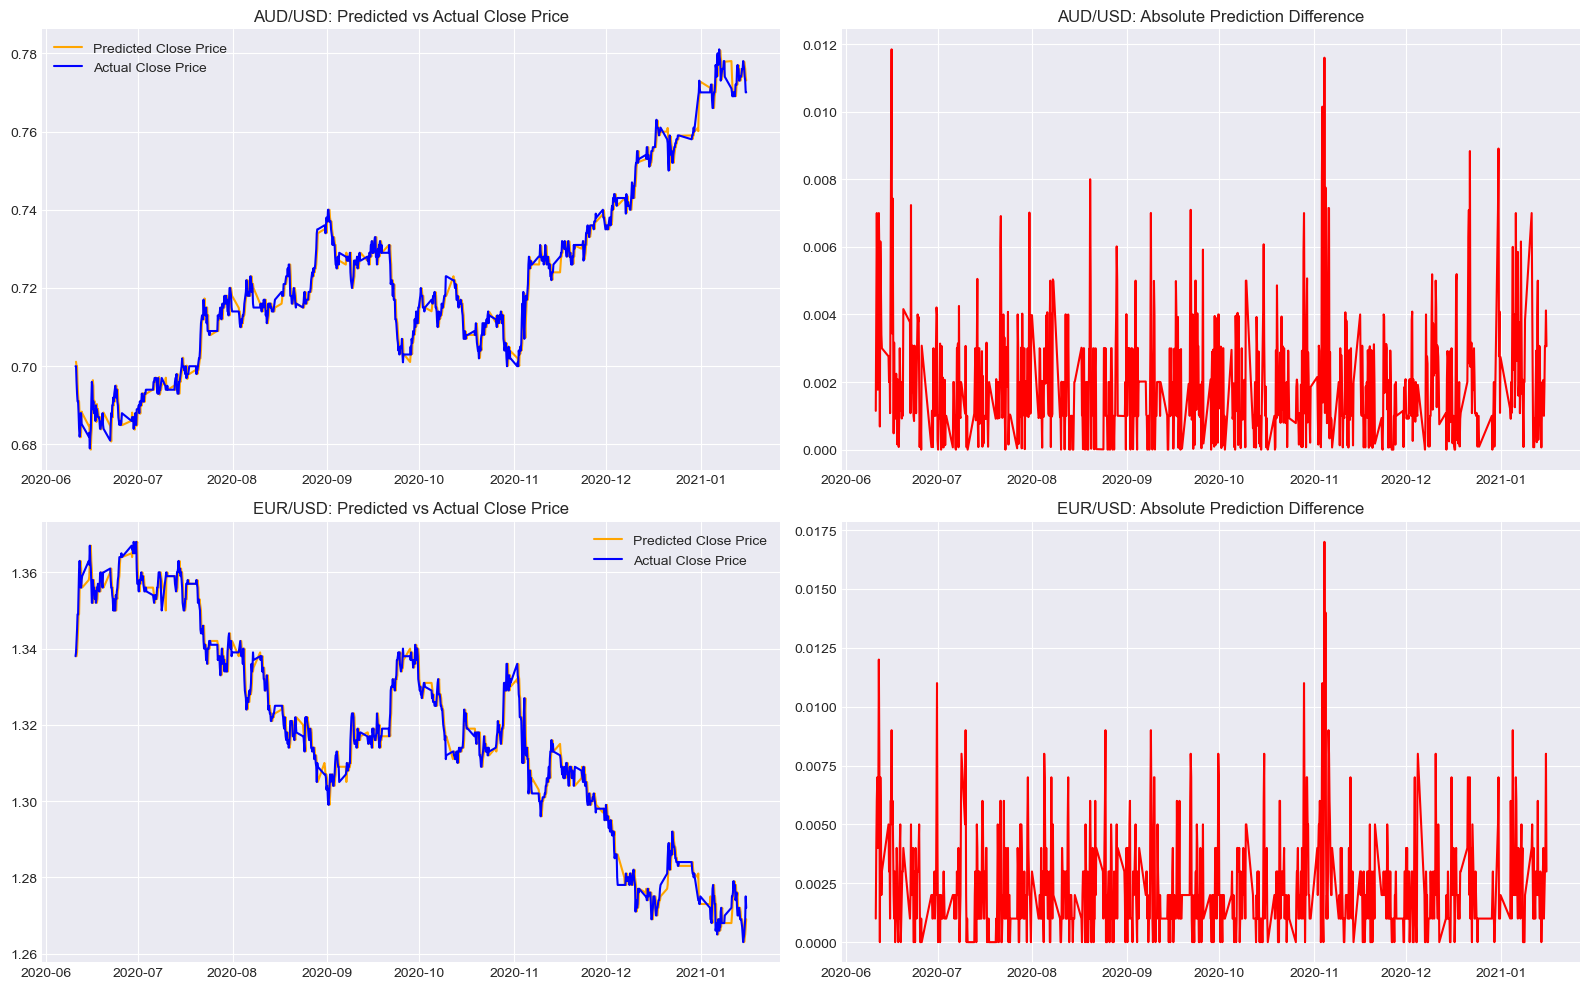

In [157]:
# Apply the window slice to remove the burn in period
test_aud = test_aud.iloc[window:]
test_eur = test_eur.iloc[window:]

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

# Subplot 1 AUD Predicted vs Actual Close Price
axes[0, 0].plot(test_aud['predicted_price'].shift(1), label='Predicted Close Price', color='orange')
axes[0, 0].plot(test_aud['close'], label='Actual Close Price', color='blue')
axes[0, 0].set_title('AUD/USD: Predicted vs Actual Close Price')
axes[0, 0].legend()

# Subplot 2 AUD Absolute Difference
aud_diff = np.abs(test_aud['predicted_price'].shift(1) - test_aud['close'])
axes[0, 1].plot(aud_diff, color='red')
axes[0, 1].set_title('AUD/USD: Absolute Prediction Difference')

# Subplot 3 EUR Predicted vs Actual Close Price
axes[1, 0].plot(test_eur['predicted_price'].shift(1), label='Predicted Close Price', color='orange')
axes[1, 0].plot(test_eur['close'], label='Actual Close Price', color='blue')
axes[1, 0].set_title('EUR/USD: Predicted vs Actual Close Price')
axes[1, 0].legend()

# Subplot 4 EUR Absolute Difference
eur_diff = np.abs(test_eur['predicted_price'].shift(1) - test_eur['close'])
axes[1, 1].plot(eur_diff, color='red')
axes[1, 1].set_title('EUR/USD: Absolute Prediction Difference')

# Adjust layout so labels do not overlap
plt.tight_layout()
plt.show()

#### Trade strategy using the predicted prices
We buy the asset if the predicted price is more than the current price.

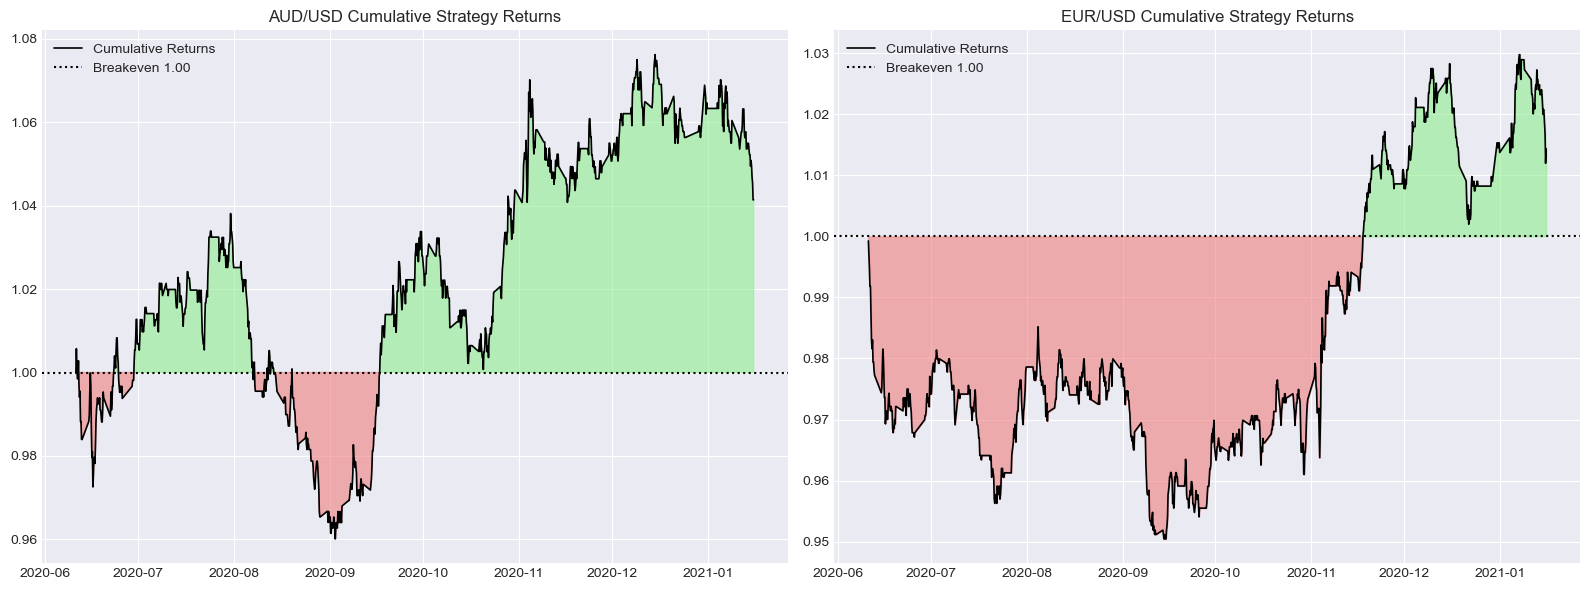

In [158]:
# Calculate signals and returns for AUD
test_aud['signal'] = np.where(test_aud['predicted_price'] > test_aud['close'], 1, -1)
test_aud['strategy_returns'] = test_aud['signal'].shift(1) * test_aud['close'].pct_change()
cum_ret_aud = (test_aud['strategy_returns'] + 1).cumprod()

# Calculate signals and returns for EUR
test_eur['signal'] = np.where(test_eur['predicted_price'] > test_eur['close'], 1, -1)
test_eur['strategy_returns'] = test_eur['signal'].shift(1) * test_eur['close'].pct_change()
cum_ret_eur = (test_eur['strategy_returns'] + 1).cumprod()

# Create a figure with 2 subplots 1 row 2 columns
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Plot AUD Cumulative Returns
axes[0].plot(cum_ret_aud, color='black', linewidth=1.2, label='Cumulative Returns')
axes[0].axhline(y=1.0, color='black', linestyle=':', label='Breakeven 1.00')
axes[0].fill_between(cum_ret_aud.index, 1.0, cum_ret_aud, where=(cum_ret_aud > 1.0), interpolate=True, color='lightgreen', alpha=0.6)
axes[0].fill_between(cum_ret_aud.index, 1.0, cum_ret_aud, where=(cum_ret_aud <= 1.0), interpolate=True, color='lightcoral', alpha=0.6)
axes[0].set_title('AUD/USD Cumulative Strategy Returns')
axes[0].legend()

# Plot EUR Cumulative Returns
axes[1].plot(cum_ret_eur, color='black', linewidth=1.2, label='Cumulative Returns')
axes[1].axhline(y=1.0, color='black', linestyle=':', label='Breakeven 1.00')
axes[1].fill_between(cum_ret_eur.index, 1.0, cum_ret_eur, where=(cum_ret_eur > 1.0), interpolate=True, color='lightgreen', alpha=0.6)
axes[1].fill_between(cum_ret_eur.index, 1.0, cum_ret_eur, where=(cum_ret_eur <= 1.0), interpolate=True, color='lightcoral', alpha=0.6)
axes[1].set_title('EUR/USD Cumulative Strategy Returns')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Performance Analysis

Start date,2020-06-10
End date,2021-01-15
Total months,10
,Backtest
Annual return,4.795%
Cumulative returns,4.174%
Annual volatility,7.861%
Sharpe ratio,0.63
Calmar ratio,0.66
Stability,0.54
Max drawdown,-7.273%


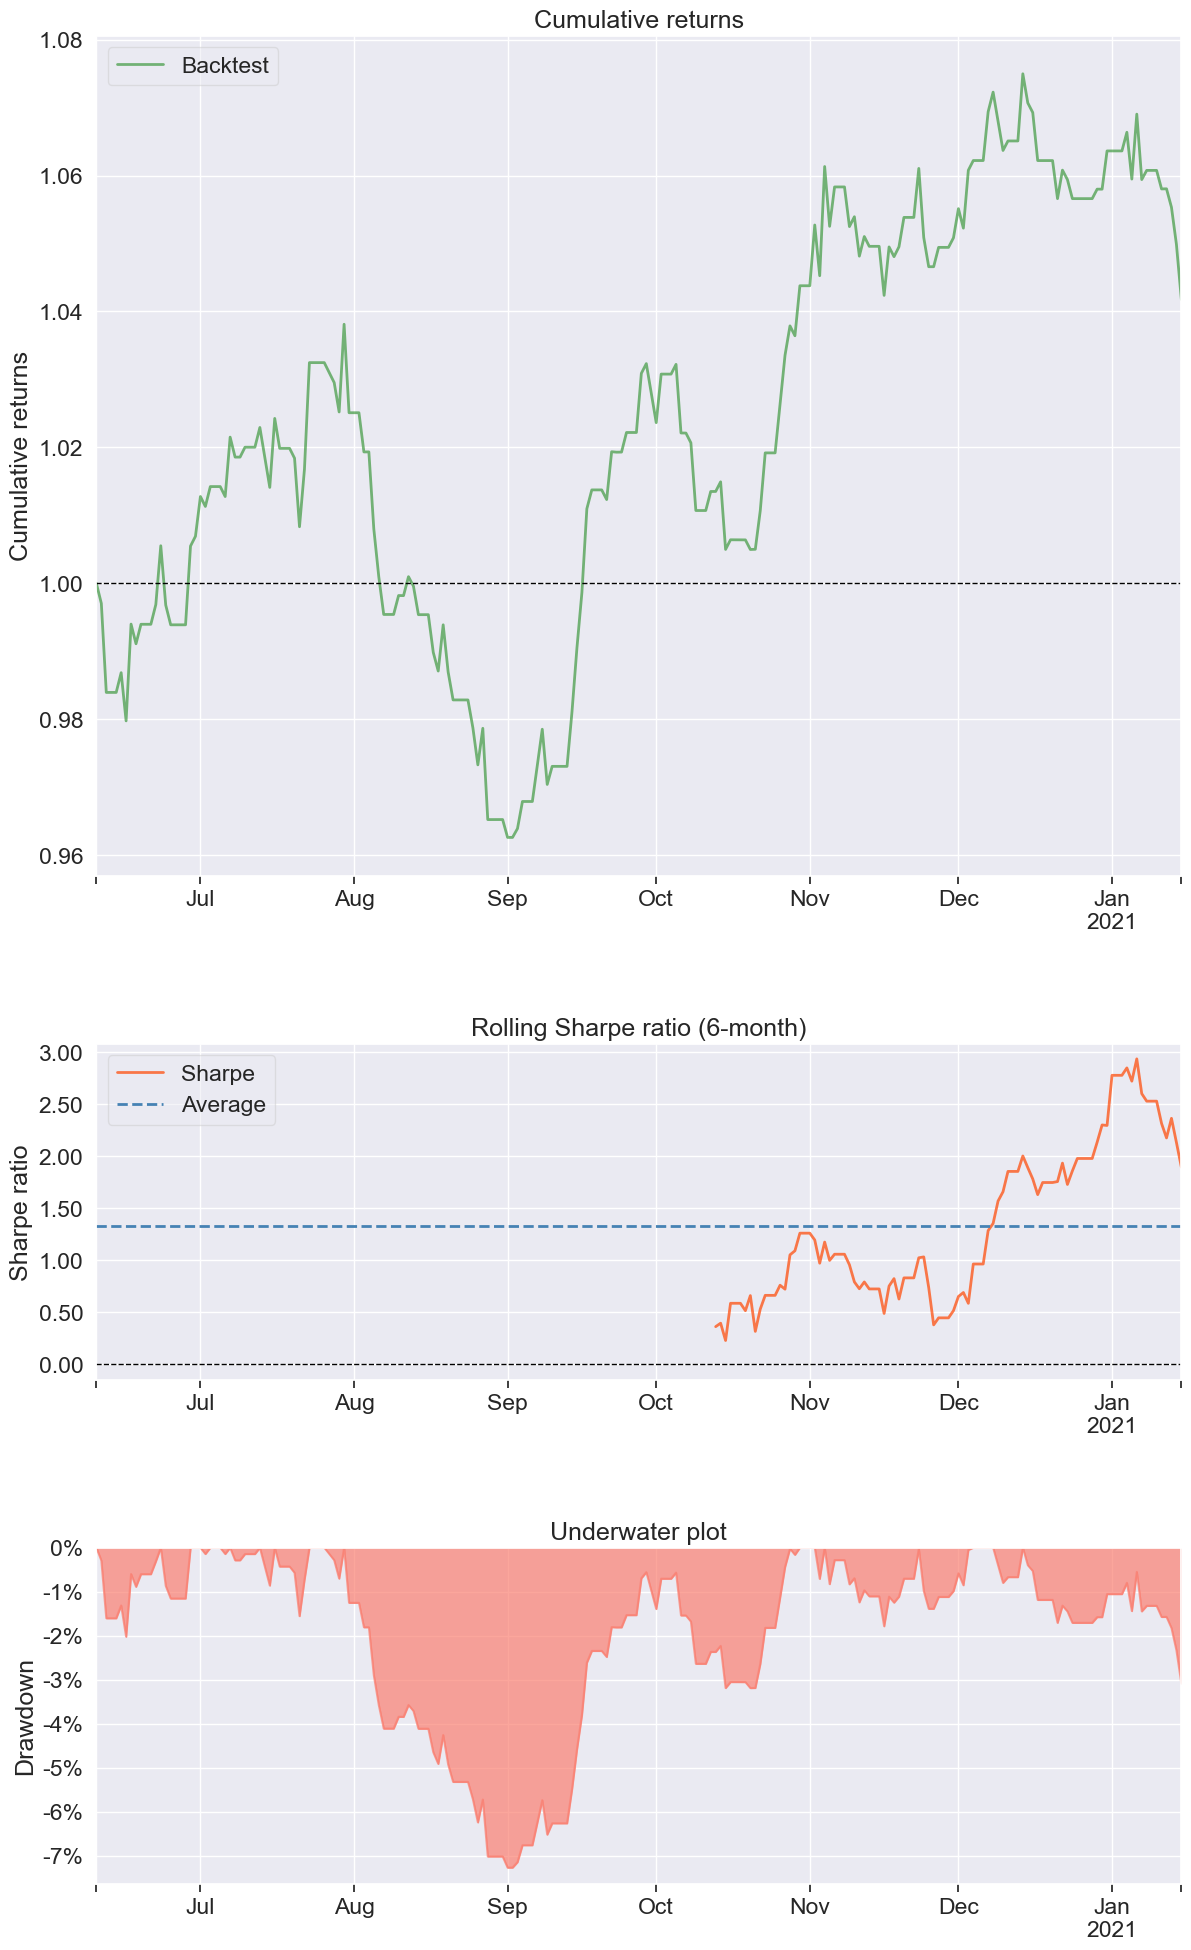

In [159]:
pf.create_simple_tear_sheet(test_aud['strategy_returns'].resample('1D').sum())

Start date,2020-06-10
End date,2021-01-15
Total months,10
,Backtest
Annual return,1.622%
Cumulative returns,1.415%
Annual volatility,5.805%
Sharpe ratio,0.31
Calmar ratio,0.33
Stability,0.52
Max drawdown,-4.973%


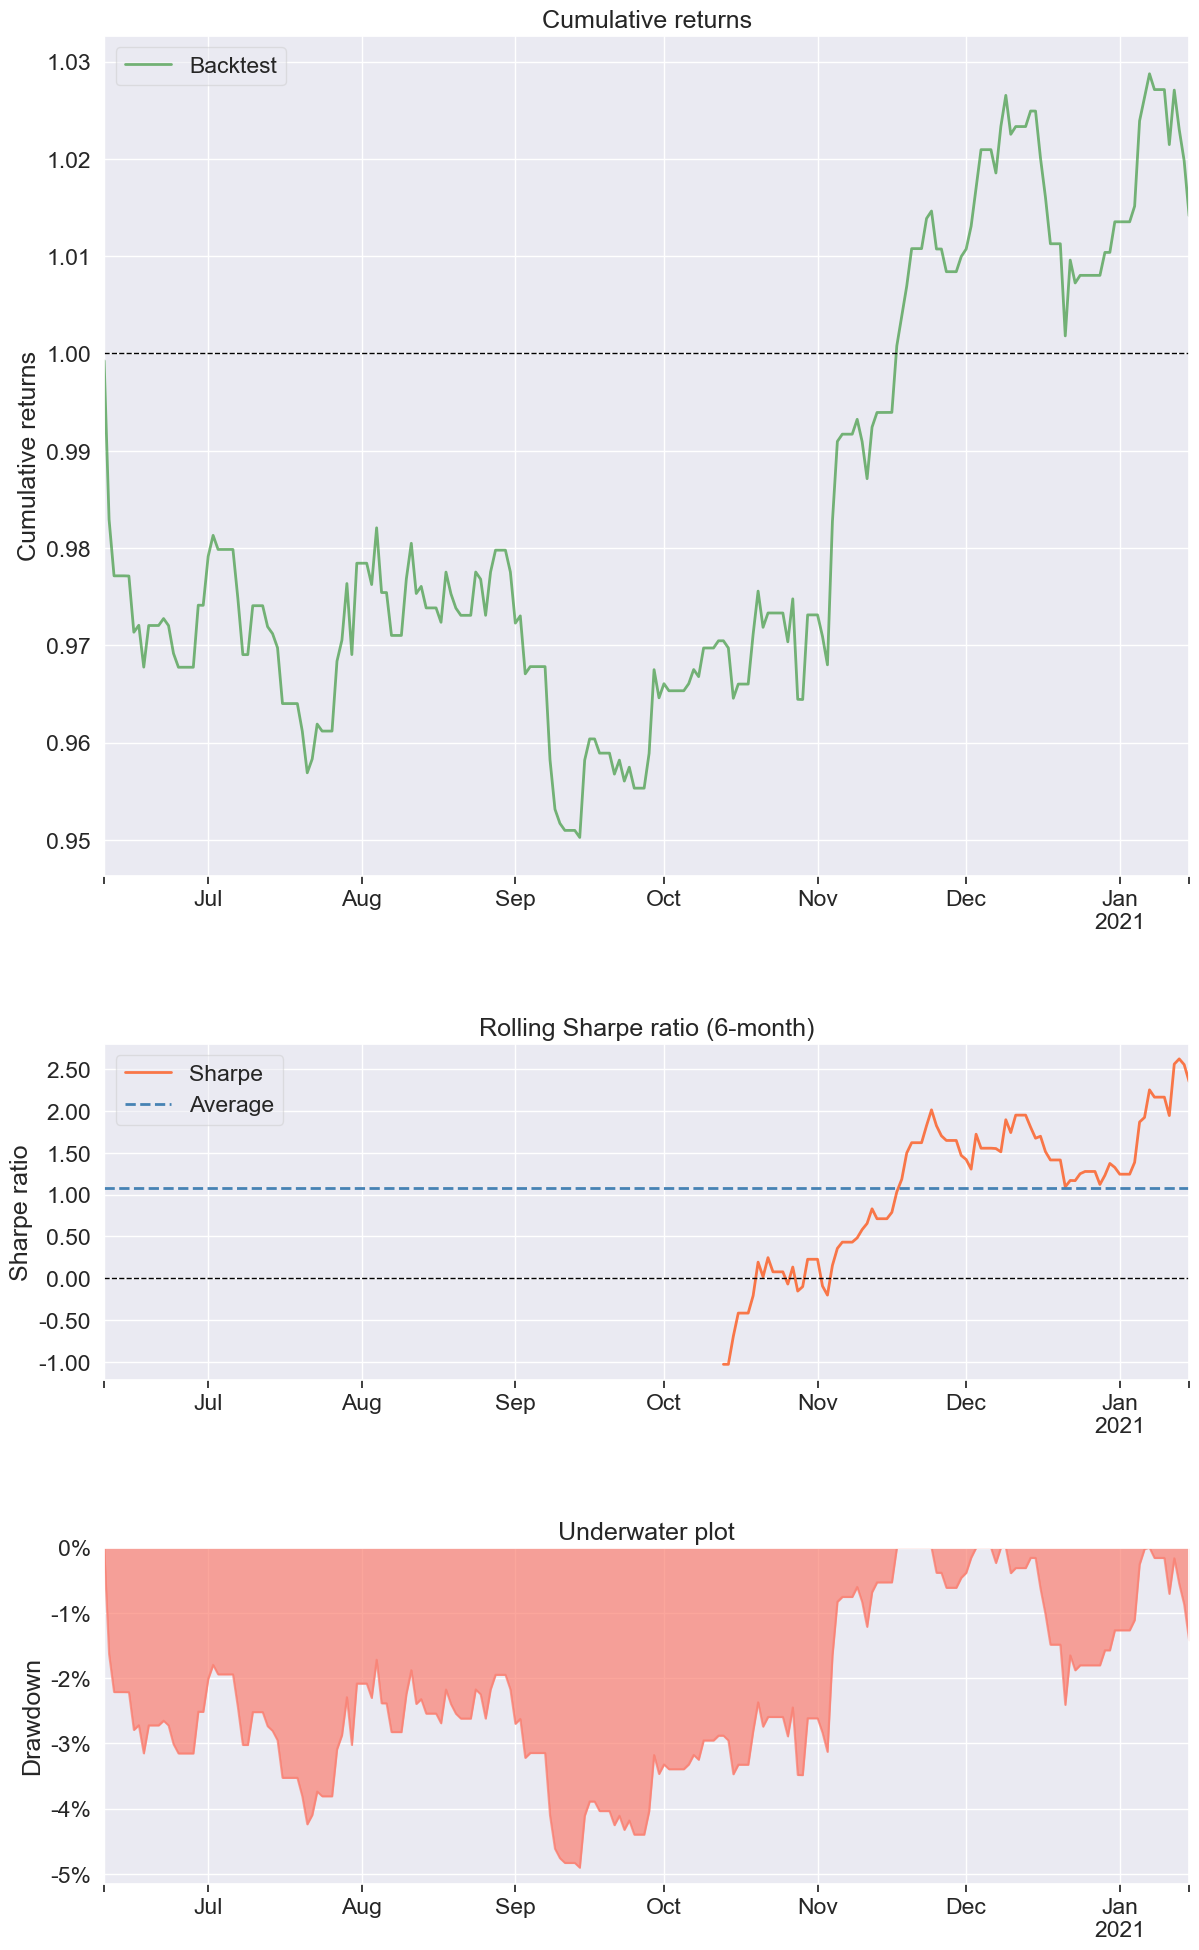

In [160]:
pf.create_simple_tear_sheet(test_eur['strategy_returns'].resample('1D').sum())